## Importing Libraries

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import time
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import image_dataset_from_directory


## GPU Setup

In [ ]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            if not tf.config.experimental.get_memory_growth(gpu):
                tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled")
    except RuntimeError as e:
        print(e)

print("GPUs:", gpus)
print("TensorFlow version:", tf.__version__)

# Mixed precision: stores weights as float32, compute as float16
# Roughly halves VRAM usage — lets larger batches fit on the same GPU
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print("Compute dtype:", mixed_precision.global_policy().compute_dtype)
print("Variable dtype:", mixed_precision.global_policy().variable_dtype)


Memory growth enabled
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.10.0
Compute dtype: float16
Variable dtype: float32


# Data Preparation

In [ ]:
DATA_DIR = "C:/Users/HP/Downloads/ML/eye_disease/train"
VAL_DIR  = "C:/Users/HP/Downloads/ML/eye_disease/val"
TEST_DIR = "C:/Users/HP/Downloads/ML/eye_disease/test"

INPUT_SHAPE = [160, 160, 3]   # 224→160: 2x fewer pixels per image, much faster
BATCH_SIZE  = 32              # safe again with mixed_float16 + smaller images
IMG_SIZE    = (160, 160)


## Dataset Overview (Basic EDA)
### We are Checking
1.Number of classes

2.Total images per class

3.Image shape & datatype

In [ ]:
classes = os.listdir(DATA_DIR)

data = []
for cls in classes:
    path = os.path.join(DATA_DIR, cls)
    count = len(os.listdir(path))
    data.append([cls, count])

df = pd.DataFrame(data, columns=["Class", "No_of_Images"])
print(df)


    Class  No_of_Images
0     CNV         26218
1     DME          8118
2  DRUSEN          6206
3  NORMAL         35973


## Class Distribution Visualization

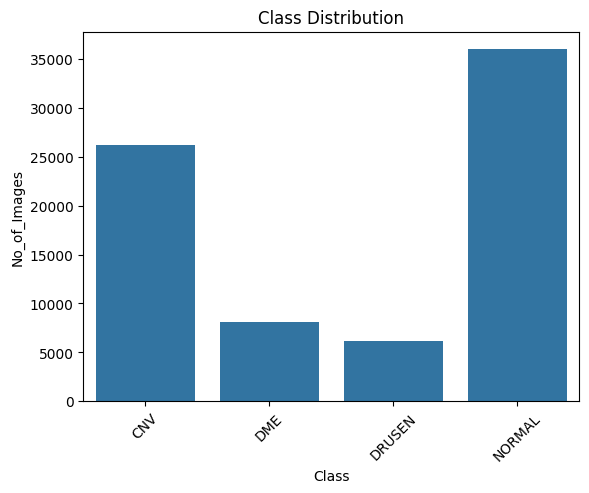

In [ ]:
sns.barplot(x=df["Class"], y=df["No_of_Images"])
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()


#### Dataset shows class imbalance, therefore on-the-fly data augmentation is applied to minority classes during training to improve model generalization and reduce bias. No extra disk space is used.

## Visual Inspection of Images
Helps detect:
Blur images, 
Wrong labels, 
Noise/artifacts

Found 76515 files belonging to 4 classes.


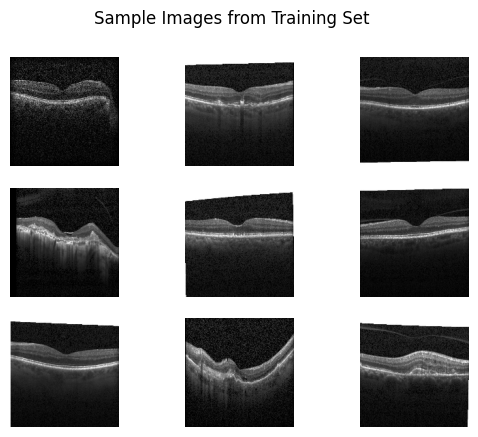

In [ ]:
raw_set = image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
)

for images, labels in raw_set.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")
plt.suptitle("Sample Images from Training Set")
plt.show()


## On-the-fly Data Augmentation (Minority Classes Only)

Augmentation is applied **only to DME and DRUSEN** (minority classes) during training using `tf.data.Dataset.map`. This runs in the data pipeline so no extra images are saved to disk.

In [ ]:
class_names_list = raw_set.class_names
print("Classes:", class_names_list)

# DME=1, DRUSEN=2 (alphabetical order from folder names)
minority_classes = tf.constant([1, 2], dtype=tf.int32)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

def augment_minority(images, labels):
    """Vectorised minority augmentation — runs entirely on GPU, no Python loop.

    Strategy: augment the whole batch at once (one GPU call), then use
    tf.where to swap in the augmented version only for DME/DRUSEN samples.
    Majority classes (CNV, NORMAL) keep their original pixels.
    This is ~20x faster than the tf.map_fn per-image loop.
    """
    images = tf.cast(images, tf.float32)

    # Augment the full batch in one vectorised GPU call
    aug_images = tf.cast(
        data_augmentation(images, training=True), tf.float32
    )

    # Build a per-image boolean mask: True where the class is a minority class
    class_indices = tf.argmax(labels, axis=1, output_type=tf.int32)  # [B]
    is_minority = tf.reduce_any(
        tf.equal(
            tf.expand_dims(class_indices, 1),   # [B, 1]
            tf.expand_dims(minority_classes, 0)  # [1, 2]
        ),
        axis=1
    )  # [B]  — True for DME and DRUSEN samples

    # Expand mask to [B, H, W, C] so tf.where broadcasts correctly
    mask = tf.reshape(is_minority, [-1, 1, 1, 1])
    mask = tf.broadcast_to(mask, tf.shape(images))

    images = tf.where(mask, aug_images, images)
    return images, labels


Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


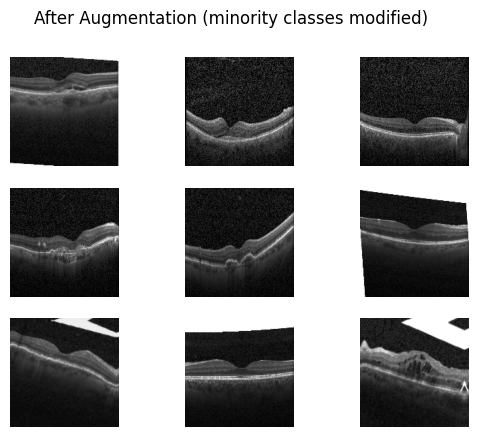

In [ ]:
# after augmentation
for images, labels in raw_set.take(1):
    aug_images, _ = augment_minority(images, labels)
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(aug_images[i].numpy().astype("uint8"))
        plt.axis("off")
plt.suptitle("After Augmentation (minority classes modified)")
plt.show()


## Building Training and Validation Datasets

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

# ── Step 1: Write TFRecord files (run once, then skip on reruns)
def write_tfrecords(data_dir, output_path, img_size):
    """Convert a folder of images into a single TFRecord file.
    Only runs if the file does not already exist.
    Uses batch_size=1 to avoid any memory issues during writing.
    Saves images as raw uint8 bytes — no float cast, no precision issues.
    """
    if os.path.exists(output_path):
        print(f"  {output_path} already exists — skipping.")
        return

    # Temporarily disable mixed precision for the write pass —
    # it causes float16 tensors which break uint8 encoding
    from tensorflow.keras import mixed_precision
    original_policy = mixed_precision.global_policy()
    mixed_precision.set_global_policy("float32")

    ds = image_dataset_from_directory(
        data_dir,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=1,        # batch_size=1: minimal RAM, never OOM
        image_size=img_size,
        shuffle=False,
        interpolation="bilinear",
    )

    writer = tf.io.TFRecordWriter(output_path)
    n = 0
    for images, labels in ds:
        img = images[0]                           # shape [H, W, 3], float32 0-255
        lbl = labels[0].numpy()                   # shape [4]
        img_uint8 = tf.cast(img, tf.uint8)        # safe: float32 -> uint8
        img_bytes = tf.image.encode_jpeg(img_uint8, quality=95).numpy()
        feature = {
            "image": tf.train.Feature(bytes_list=tf.train.BytesList(value=[img_bytes])),
            "label": tf.train.Feature(float_list=tf.train.FloatList(value=lbl.tolist())),
        }
        writer.write(tf.train.Example(
            features=tf.train.Features(feature=feature)
        ).SerializeToString())
        n += 1
        if n % 5000 == 0:
            print(f"    {n} images written...")

    writer.close()
    # Restore mixed precision policy
    mixed_precision.set_global_policy(original_policy)
    print(f"  Done — {n} records written to {output_path}")


# ── Step 2: Read TFRecords back as a streaming dataset
def read_tfrecords(path, img_size, num_classes=4):
    h, w = img_size

    def parse(serialised):
        features = tf.io.parse_single_example(serialised, {
            "image": tf.io.FixedLenFeature([], tf.string),
            "label": tf.io.FixedLenFeature([num_classes], tf.float32),
        })
        img = tf.image.decode_jpeg(features["image"], channels=3)
        img = tf.image.resize(img, [h, w])
        img = tf.cast(img, tf.float32) / 255.0
        return img, features["label"]

    return tf.data.TFRecordDataset(path).map(parse, num_parallel_calls=AUTOTUNE)


# ── Step 3: Build training / eval datasets
def build_train_ds(tfrecord_path, img_size, batch_size, n_samples):
    ds = read_tfrecords(tfrecord_path, img_size)
    ds = ds.shuffle(buffer_size=2000, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size)
    ds = ds.map(augment_minority, num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

def build_eval_ds(tfrecord_path, img_size, batch_size):
    ds = read_tfrecords(tfrecord_path, img_size)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds


# ── Write TFRecords once (safe to re-run — skips existing files)
TFRECORD_DIR = "C:/Users/HP/Downloads/ML/eye_disease/tfrecords"
os.makedirs(TFRECORD_DIR, exist_ok=True)

TRAIN_TFR_160 = os.path.join(TFRECORD_DIR, "train_160.tfrecord")
VAL_TFR_160   = os.path.join(TFRECORD_DIR, "val_160.tfrecord")
TRAIN_TFR_128 = os.path.join(TFRECORD_DIR, "train_128.tfrecord")
VAL_TFR_128   = os.path.join(TFRECORD_DIR, "val_128.tfrecord")
TEST_TFR_160  = os.path.join(TFRECORD_DIR, "test_160.tfrecord")
TEST_TFR_128  = os.path.join(TFRECORD_DIR, "test_128.tfrecord")

print("Writing TFRecords (skips if already done)...")
write_tfrecords(DATA_DIR, TRAIN_TFR_160, IMG_SIZE)
write_tfrecords(VAL_DIR,  VAL_TFR_160,   IMG_SIZE)
write_tfrecords(DATA_DIR, TRAIN_TFR_128, (128, 128))
write_tfrecords(VAL_DIR,  VAL_TFR_128,   (128, 128))
write_tfrecords(TEST_DIR, TEST_TFR_160,  IMG_SIZE)
write_tfrecords(TEST_DIR, TEST_TFR_128,  (128, 128))
print("All TFRecords ready.")

# ── Build MobileNetV3 / ResNet50 / EfficientNet datasets (160x160)
N_TRAIN = sum(len(os.listdir(os.path.join(DATA_DIR, c))) for c in os.listdir(DATA_DIR))
training_set   = build_train_ds(TRAIN_TFR_160, IMG_SIZE, BATCH_SIZE, N_TRAIN)
validation_set = build_eval_ds(VAL_TFR_160,   IMG_SIZE, BATCH_SIZE)

print("Datasets ready.")


Writing TFRecords (skips if already done)...
  C:/Users/HP/Downloads/ML/eye_disease/tfrecords\train_160.tfrecord already exists — skipping.
Found 21861 files belonging to 4 classes.
    5000 images written...
    10000 images written...
    15000 images written...
    20000 images written...
  Done — 21861 records written to C:/Users/HP/Downloads/ML/eye_disease/tfrecords\val_160.tfrecord
Found 76515 files belonging to 4 classes.
    5000 images written...
    10000 images written...
    15000 images written...
    20000 images written...
    25000 images written...
    30000 images written...
    35000 images written...
    40000 images written...
    45000 images written...
    50000 images written...
    55000 images written...
    60000 images written...
    65000 images written...
    70000 images written...
    75000 images written...
  Done — 76515 records written to C:/Users/HP/Downloads/ML/eye_disease/tfrecords\train_128.tfrecord
Found 21861 files belonging to 4 classes.
    50

In [ ]:
import tensorflow_addons as tfa

number_of_classes = df["Class"].nunique()

def make_metrics():
    return [
        "accuracy",
        tfa.metrics.F1Score(num_classes=number_of_classes, average="macro"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]


In [ ]:
def evaluate_model(model, test_ds, model_name):
    results = model.evaluate(test_ds, verbose=1)
    loss, acc, f1, prec, rec = results

    y_true, y_pred = [], []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    class_names_eval = ["CNV", "DME", "DRUSEN", "NORMAL"]
    print(classification_report(y_true, y_pred, target_names=class_names_eval))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names_eval, yticklabels=class_names_eval)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — Test Set ({model_name})")
    plt.tight_layout()
    plt.show()

    return acc, prec, rec, loss


# MobileNetV3Large

## Setting Parameters for Training on MobileNetV3Large Model

In [ ]:
mobnet = tf.keras.applications.MobileNetV3Large(
    input_shape=INPUT_SHAPE,
    alpha=1.0,
    minimalistic=False,
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    classes=1000,
    pooling="avg",
    dropout_rate=0.2,
    classifier_activation="softmax",
    include_preprocessing=False,
)


### Adding Layers

In [ ]:
#Initialize empty model
mob_model = tf.keras.models.Sequential()

#input layer
mob_model.add(tf.keras.layers.Input(shape=INPUT_SHAPE))


### Normalization

Data is already normalized in the pipeline (divided by 255). Here we rescale to [-1, 1] as expected by MobileNetV3.

In [ ]:
#Normalization  ( pipeline gives [0,1] → rescale to [-1,1] )
mob_model.add(tf.keras.layers.Rescaling(scale=2.0, offset=-1.0))


In [ ]:
# adding mobile net architecture
mob_model.add(mobnet)

# output layers and Dense layers
mob_model.add(tf.keras.layers.Dense(units=4, activation="softmax"))


### Adding Evaluation Metrics

In [ ]:
mob_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=make_metrics()
)

mob_model.summary()


Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_3 (Rescaling)     (None, 160, 160, 3)       0         
                                                                 
 MobilenetV3large (Functiona  (None, 960)              2996352   
 l)                                                              
                                                                 
 dense_3 (Dense)             (None, 4)                 3844      
                                                                 
Total params: 3,000,196
Trainable params: 2,975,796
Non-trainable params: 24,400
_________________________________________________________________


# Training MobileNetV3

In [ ]:
t0 = time.time()
mob_history = mob_model.fit(training_set, validation_data=validation_set, epochs=30)
mob_train_time = time.time() - t0
print(f"MobileNetV3 training time: {mob_train_time:.1f}s")


Epoch 1/30
2/2 [==============================] - 88s 74s/step - loss: 1.4019 - accuracy: 0.3438 - f1_score: 0.1279 - precision: 0.3077 - recall: 0.1250 - val_loss: 3.4176 - val_accuracy: 0.1327 - val_f1_score: 0.0914 - val_precision: 0.1238 - val_recall: 0.1177
Epoch 2/30
2/2 [==============================] - 73s 72s/step - loss: 1.3223 - accuracy: 0.4531 - f1_score: 0.1559 - precision: 0.4400 - recall: 0.1719 - val_loss: 3.4145 - val_accuracy: 0.1410 - val_f1_score: 0.1003 - val_precision: 0.1309 - val_recall: 0.1242
Epoch 3/30
2/2 [==============================] - 73s 72s/step - loss: 0.8755 - accuracy: 0.7969 - f1_score: 0.2217 - precision: 0.8788 - recall: 0.4531 - val_loss: 3.4225 - val_accuracy: 0.1497 - val_f1_score: 0.1090 - val_precision: 0.1391 - val_recall: 0.1319
Epoch 4/30
2/2 [==============================] - 73s 72s/step - loss: 0.4769 - accuracy: 0.9688 - f1_score: 0.2460 - precision: 1.0000 - recall: 0.8750 - val_loss: 3.4249 - val_accuracy: 0.1614 - val_f1_score: 

### Seeing the Evaluation Metrics

342/342 [==============================] - 37s 108ms/step - loss: 3.5181 - accuracy: 0.2384 - f1_score: 0.1481 - precision: 0.2372 - recall: 0.2297


c:\Users\HP\anaconda3\envs\ds_proj_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\HP\anaconda3\envs\ds_proj_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\HP\anaconda3\envs\ds_proj_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

         CNV       0.39      0.59      0.47      3745
         DME       0.07      0.33      0.12      1161
      DRUSEN       0.00      0.00      0.00       887
      NORMAL       0.00      0.00      0.00      5139

    accuracy                           0.24     10932
   macro avg       0.12      0.23      0.15     10932
weighted avg       0.14      0.24      0.17     10932



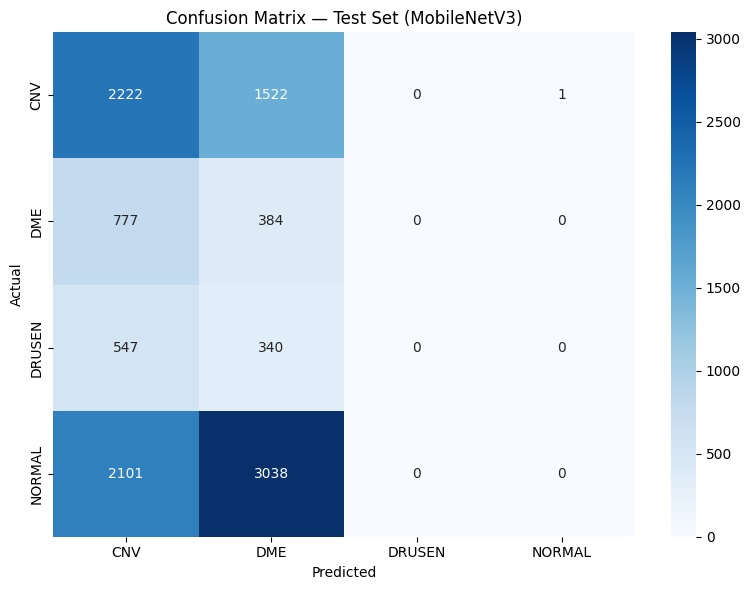

In [ ]:
test_set_mob = build_eval_ds(TEST_TFR_160, IMG_SIZE, BATCH_SIZE)
mob_test_acc, mob_test_prec, mob_test_rec, mob_test_loss = evaluate_model(mob_model, test_set_mob, "MobileNetV3")

mob_train_acc  = mob_history.history['accuracy'][-1]
mob_val_acc    = mob_history.history['val_accuracy'][-1]
mob_train_loss = mob_history.history['loss'][-1]
mob_val_loss   = mob_history.history['val_loss'][-1]


# Saving MobileNetV3

In [ ]:
mob_model.save("trained_eye_mobilenet.keras")

import pickle
with open("training_history_mobilenet.pkl", "wb") as f:
    pickle.dump(mob_history.history, f)


### loss visualisation

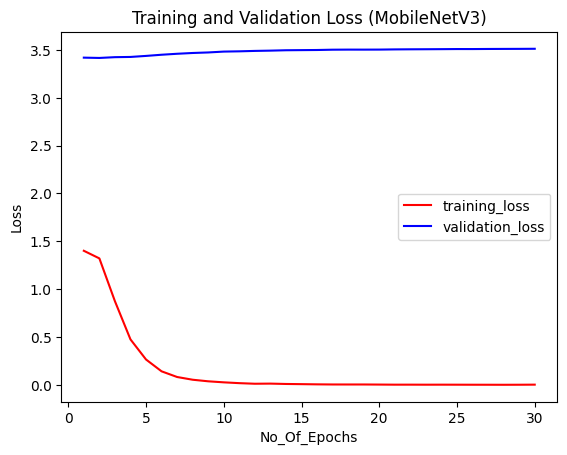

In [ ]:
epochs = [i for i in range(1, 31)]
plt.plot(epochs, mob_history.history['loss'], color='red', label="training_loss")
plt.plot(epochs, mob_history.history['val_loss'], color='blue', label="validation_loss")
plt.xlabel("No_Of_Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (MobileNetV3)")
plt.legend()
plt.show()


# Custom CNN

## Setting Parameters for Training on Custom CNN

In [ ]:
CNN_INPUT_SHAPE = [128, 128, 3]

N_TRAIN_CNN = N_TRAIN  # same source folder
cnn_train_set = build_train_ds(TRAIN_TFR_128, (128, 128), BATCH_SIZE, N_TRAIN_CNN)
cnn_val_set   = build_eval_ds(VAL_TFR_128,   (128, 128), BATCH_SIZE)


### Building the CNN

In [ ]:
from tensorflow.keras import layers

cnn_model = tf.keras.models.Sequential([
    layers.Input(shape=CNN_INPUT_SHAPE),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
])


### Adding Evaluation Metrics

In [ ]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=make_metrics()
)

cnn_model.summary()


Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 128, 128, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 64, 64, 64)       256       
 hNormalization)                                                 
                                                     

# Training CNN

In [ ]:
t0 = time.time()
cnn_history = cnn_model.fit(cnn_train_set, validation_data=cnn_val_set, epochs=30)
cnn_train_time = time.time() - t0
print(f"CNN training time: {cnn_train_time:.1f}s")


Epoch 1/30
2392/2392 [==============================] - 182s 74ms/step - loss: 0.5839 - accuracy: 0.9715 - f1_score: 0.9314 - precision: 0.9733 - recall: 0.9691 - val_loss: 50.5442 - val_accuracy: 0.4702 - val_f1_score: 0.1599 - val_precision: 0.4702 - val_recall: 0.4702
Epoch 2/30
2392/2392 [==============================] - 176s 73ms/step - loss: 0.2619 - accuracy: 0.9525 - f1_score: 0.9038 - precision: 0.9688 - recall: 0.9399 - val_loss: 39.6269 - val_accuracy: 0.4702 - val_f1_score: 0.1599 - val_precision: 0.4702 - val_recall: 0.4702
Epoch 3/30
2392/2392 [==============================] - 176s 73ms/step - loss: 0.2431 - accuracy: 0.9646 - f1_score: 0.9266 - precision: 0.9762 - recall: 0.9296 - val_loss: 28.1699 - val_accuracy: 0.4702 - val_f1_score: 0.1599 - val_precision: 0.4702 - val_recall: 0.4702
Epoch 4/30
2392/2392 [==============================] - 173s 72ms/step - loss: 0.2313 - accuracy: 0.9642 - f1_score: 0.9295 - precision: 0.9658 - recall: 0.9623 - val_loss: 16.8959 - v

### Seeing the Evaluation Metrics

342/342 [==============================] - 6s 16ms/step - loss: 2.7801 - accuracy: 0.4698 - f1_score: 0.1599 - precision: 0.4698 - recall: 0.4698


c:\Users\HP\anaconda3\envs\ds_proj_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\HP\anaconda3\envs\ds_proj_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\HP\anaconda3\envs\ds_proj_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

         CNV       0.00      0.00      0.00      3745
         DME       0.00      0.00      0.00      1161
      DRUSEN       0.00      0.00      0.00       887
      NORMAL       0.47      1.00      0.64      5139

    accuracy                           0.47     10932
   macro avg       0.12      0.25      0.16     10932
weighted avg       0.22      0.47      0.30     10932



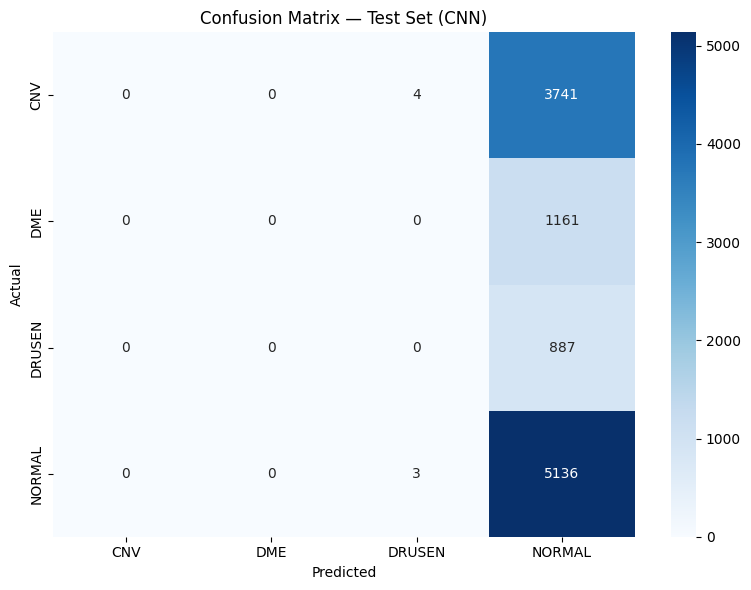

In [ ]:
test_set_cnn = build_eval_ds(TEST_TFR_128, (128, 128), BATCH_SIZE)
cnn_test_acc, cnn_test_prec, cnn_test_rec, cnn_test_loss = evaluate_model(cnn_model, test_set_cnn, "CNN")

cnn_train_acc  = cnn_history.history['accuracy'][-1]
cnn_val_acc    = cnn_history.history['val_accuracy'][-1]
cnn_train_loss = cnn_history.history['loss'][-1]
cnn_val_loss   = cnn_history.history['val_loss'][-1]


# Saving CNN

In [ ]:
cnn_model.save("trained_eye_cnn.keras")

import pickle
with open("training_history_cnn.pkl", "wb") as f:
    pickle.dump(cnn_history.history, f)


### loss visualisation

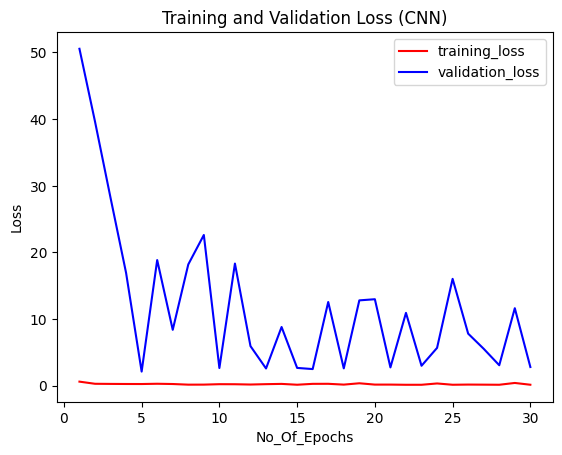

In [ ]:
epochs = [i for i in range(1, 31)]
plt.plot(epochs, cnn_history.history['loss'], color='red', label="training_loss")
plt.plot(epochs, cnn_history.history['val_loss'], color='blue', label="validation_loss")
plt.xlabel("No_Of_Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (CNN)")
plt.legend()
plt.show()


# ResNet50

## Setting Parameters for Training on ResNet50 Model

In [ ]:
resnet = tf.keras.applications.ResNet50(
    input_shape=INPUT_SHAPE,
    include_top=False,
    weights="imagenet",
    pooling="avg",
)


### Adding Layers

In [ ]:
#Initialize empty model
rn_model = tf.keras.models.Sequential()

#input layer
rn_model.add(tf.keras.layers.Input(shape=INPUT_SHAPE))


### Normalization

In [ ]:
#Normalization  ( pipeline gives [0,1] → rescale to [-1,1] )
rn_model.add(tf.keras.layers.Rescaling(scale=2.0, offset=-1.0))


In [ ]:
# adding resnet50 architecture
rn_model.add(resnet)

# output layers and Dense layers
rn_model.add(tf.keras.layers.Dense(units=4, activation="softmax"))


### Adding Evaluation Metrics

In [ ]:
rn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=make_metrics()
)

rn_model.summary()


Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_4 (Rescaling)     (None, 160, 160, 3)       0         
                                                                 
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 dense_6 (Dense)             (None, 4)                 8196      
                                                                 
Total params: 23,595,908
Trainable params: 23,542,788
Non-trainable params: 53,120
_________________________________________________________________


# Training ResNet50

In [ ]:
t0 = time.time()
rn_history = rn_model.fit(training_set, validation_data=validation_set, epochs=30)
rn_train_time = time.time() - t0
print(f"ResNet50 training time: {rn_train_time:.1f}s")


Epoch 1/30
2/2 [==============================] - 51s 33s/step - loss: 0.4976 - accuracy: 1.0000 - f1_score: 0.2500 - precision: 1.0000 - recall: 0.8281 - val_loss: 1.7907 - val_accuracy: 0.0811 - val_f1_score: 0.0375 - val_precision: 0.0769 - val_recall: 0.0404
Epoch 2/30
2/2 [==============================] - 32s 31s/step - loss: 0.1666 - accuracy: 1.0000 - f1_score: 0.2500 - precision: 1.0000 - recall: 0.9688 - val_loss: 1.8602 - val_accuracy: 0.0811 - val_f1_score: 0.0375 - val_precision: 0.0792 - val_recall: 0.0725
Epoch 3/30
2/2 [==============================] - 32s 31s/step - loss: 0.0260 - accuracy: 1.0000 - f1_score: 0.2500 - precision: 1.0000 - recall: 1.0000 - val_loss: 1.8982 - val_accuracy: 0.0811 - val_f1_score: 0.0375 - val_precision: 0.0806 - val_recall: 0.0793
Epoch 4/30
2/2 [==============================] - 32s 31s/step - loss: 0.0084 - accuracy: 1.0000 - f1_score: 0.2500 - precision: 1.0000 - recall: 1.0000 - val_loss: 1.9262 - val_accuracy: 0.0811 - val_f1_score: 

### Seeing the Evaluation Metrics

342/342 [==============================] - 16s 48ms/step - loss: 2.1670 - accuracy: 0.0811 - f1_score: 0.0375 - precision: 0.0812 - recall: 0.0811


c:\Users\HP\anaconda3\envs\ds_proj_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\HP\anaconda3\envs\ds_proj_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\HP\anaconda3\envs\ds_proj_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

         CNV       0.00      0.00      0.00      3745
         DME       0.00      0.00      0.00      1161
      DRUSEN       0.08      1.00      0.15       887
      NORMAL       0.00      0.00      0.00      5139

    accuracy                           0.08     10932
   macro avg       0.02      0.25      0.04     10932
weighted avg       0.01      0.08      0.01     10932



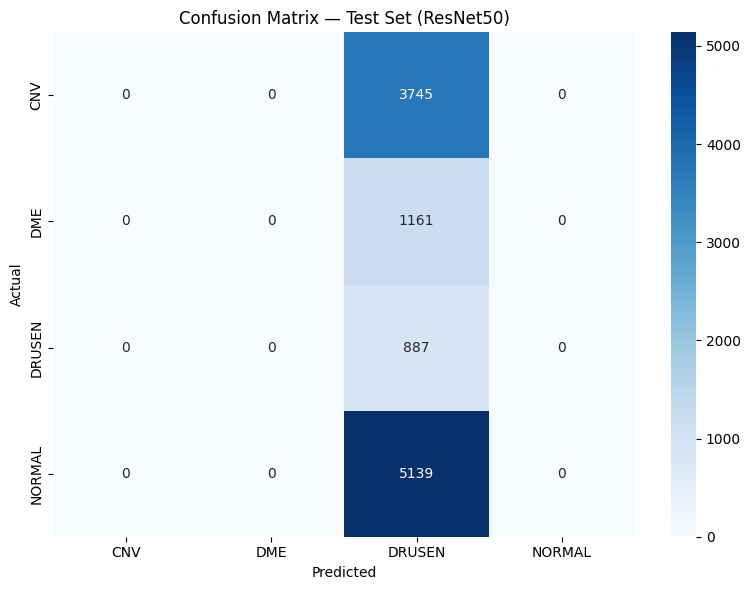

In [ ]:
test_set_rn = build_eval_ds(TEST_TFR_160, IMG_SIZE, BATCH_SIZE)
rn_test_acc, rn_test_prec, rn_test_rec, rn_test_loss = evaluate_model(rn_model, test_set_rn, "ResNet50")

rn_train_acc  = rn_history.history['accuracy'][-1]
rn_val_acc    = rn_history.history['val_accuracy'][-1]
rn_train_loss = rn_history.history['loss'][-1]
rn_val_loss   = rn_history.history['val_loss'][-1]


# Saving ResNet50

In [ ]:
rn_model.save("trained_eye_resnet50.keras")

import pickle
with open("training_history_resnet50.pkl", "wb") as f:
    pickle.dump(rn_history.history, f)


### loss visualisation

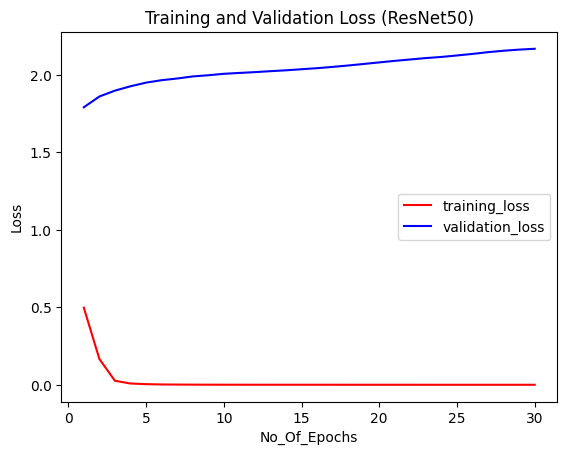

In [ ]:
epochs = [i for i in range(1, 31)]
plt.plot(epochs, rn_history.history['loss'], color='red', label="training_loss")
plt.plot(epochs, rn_history.history['val_loss'], color='blue', label="validation_loss")
plt.xlabel("No_Of_Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (ResNet50)")
plt.legend()
plt.show()


# EfficientNetB0

## Setting Parameters for Training on EfficientNetB0 Model

In [ ]:
effnet = tf.keras.applications.EfficientNetB0(
    input_shape=INPUT_SHAPE,
    include_top=False,
    weights="imagenet",
    pooling="avg",
)


### Adding Layers

In [ ]:
#Initialize empty model
en_model = tf.keras.models.Sequential()

#input layer
en_model.add(tf.keras.layers.Input(shape=INPUT_SHAPE))


### Normalization

In [ ]:
#Normalization  ( pipeline gives [0,1] → rescale to [-1,1] )
en_model.add(tf.keras.layers.Rescaling(scale=2.0, offset=-1.0))


In [ ]:
# adding efficientnetb0 architecture
en_model.add(effnet)

# output layers and Dense layers
en_model.add(tf.keras.layers.Dense(units=4, activation="softmax"))


### Adding Evaluation Metrics

In [ ]:
en_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=make_metrics()
)

en_model.summary()


Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_7 (Rescaling)     (None, 160, 160, 3)       0         
                                                                 
 efficientnetb0 (Functional)  (None, 1280)             4049571   
                                                                 
 dense_7 (Dense)             (None, 4)                 5124      
                                                                 
Total params: 4,054,695
Trainable params: 4,012,672
Non-trainable params: 42,023
_________________________________________________________________


# Training EfficientNetB0

In [ ]:
t0 = time.time()
en_history = en_model.fit(training_set, validation_data=validation_set, epochs=30)
en_train_time = time.time() - t0
print(f"EfficientNetB0 training time: {en_train_time:.1f}s")


Epoch 1/30
2/2 [==============================] - 163s 143s/step - loss: 1.6167 - accuracy: 0.1250 - f1_score: 0.0556 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 1.6949 - val_accuracy: 0.0811 - val_f1_score: 0.0375 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30
2/2 [==============================] - 142s 142s/step - loss: 1.5947 - accuracy: 0.0938 - f1_score: 0.0429 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 1.6842 - val_accuracy: 0.0811 - val_f1_score: 0.0375 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/30
2/2 [==============================] - 155s 155s/step - loss: 1.5728 - accuracy: 0.0781 - f1_score: 0.0362 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 1.6777 - val_accuracy: 0.0811 - val_f1_score: 0.0375 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/30
2/2 [==============================] - 174s 173s/step - loss: 1.3740 - accuracy: 0.3438 - f1_score: 0.1279 - precision: 0.0000e+00 - recall: 0.000

### Seeing the Evaluation Metrics

342/342 [==============================] - 71s 208ms/step - loss: 1.6523 - accuracy: 0.0811 - f1_score: 0.0375 - precision: 0.0000e+00 - recall: 0.0000e+00


c:\Users\HP\anaconda3\envs\ds_proj_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\HP\anaconda3\envs\ds_proj_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\HP\anaconda3\envs\ds_proj_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

         CNV       0.00      0.00      0.00      3745
         DME       0.00      0.00      0.00      1161
      DRUSEN       0.08      1.00      0.15       887
      NORMAL       0.00      0.00      0.00      5139

    accuracy                           0.08     10932
   macro avg       0.02      0.25      0.04     10932
weighted avg       0.01      0.08      0.01     10932



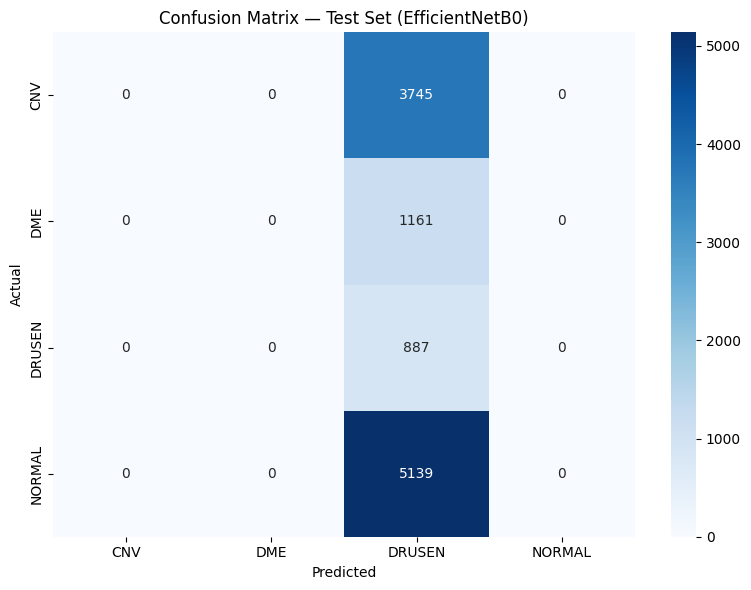

In [ ]:
test_set_en = build_eval_ds(TEST_TFR_160, IMG_SIZE, BATCH_SIZE)
en_test_acc, en_test_prec, en_test_rec, en_test_loss = evaluate_model(en_model, test_set_en, "EfficientNetB0")

en_train_acc  = en_history.history['accuracy'][-1]
en_val_acc    = en_history.history['val_accuracy'][-1]
en_train_loss = en_history.history['loss'][-1]
en_val_loss   = en_history.history['val_loss'][-1]


# Saving EfficientNetB0

In [ ]:
#en_model.save("trained_eye_efficientnet.h5")

# import pickle
# with open("training_history_efficientnet.pkl", "wb") as f:
#     pickle.dump(en_history.history, f)


### loss visualisation

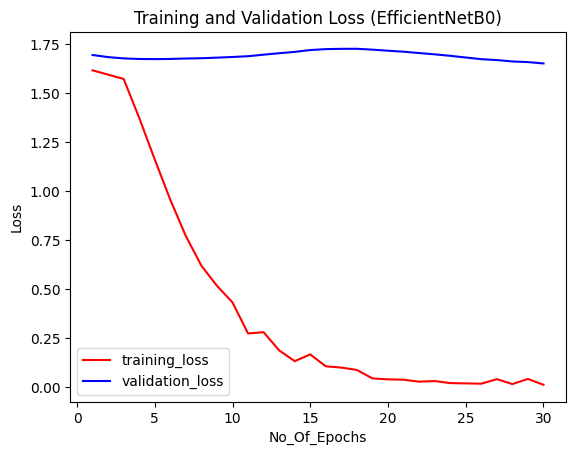

In [ ]:
epochs = [i for i in range(1, 31)]
plt.plot(epochs, en_history.history['loss'], color='red', label="training_loss")
plt.plot(epochs, en_history.history['val_loss'], color='blue', label="validation_loss")
plt.xlabel("No_Of_Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (EfficientNetB0)")
plt.legend()
plt.show()


# Model Comparison

## Summary Table — Accuracy, Precision, Recall and Training Time

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["MobileNetV3", "CNN", "ResNet50", "EfficientNetB0"],
    "Train Acc": [
        round(mob_train_acc, 4), round(cnn_train_acc, 4),
        round(rn_train_acc, 4),  round(en_train_acc, 4),
    ],
    "Val Acc": [
        round(mob_val_acc, 4), round(cnn_val_acc, 4),
        round(rn_val_acc, 4),  round(en_val_acc, 4),
    ],
    "Test Acc": [
        round(mob_test_acc, 4), round(cnn_test_acc, 4),
        round(rn_test_acc, 4),  round(en_test_acc, 4),
    ],
    "Test Precision": [
        round(mob_test_prec, 4), round(cnn_test_prec, 4),
        round(rn_test_prec, 4),  round(en_test_prec, 4),
    ],
    "Test Recall": [
        round(mob_test_rec, 4), round(cnn_test_rec, 4),
        round(rn_test_rec, 4),  round(en_test_rec, 4),
    ],
    "Train Time (s)": [
        round(mob_train_time, 1), round(cnn_train_time, 1),
        round(rn_train_time, 1),  round(en_train_time, 1),
    ],
})

print(comparison_df.to_string(index=False))


         Model  Train Acc  Val Acc  Test Acc  Test Precision  Test Recall  Train Time (s)
   MobileNetV3     1.0000   0.2453    0.2384          0.2372       0.2297          2222.5
           CNN     0.9724   0.4698    0.4698          0.4698       0.4698          5201.0
      ResNet50     1.0000   0.0811    0.0811          0.0812       0.0811           995.1
EfficientNetB0     1.0000   0.0811    0.0811          0.0000       0.0000          4355.7


## Comparison Graphs

C:\Users\HP\AppData\Local\Temp\ipykernel_4688\2665627948.py:32: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(model_names, rotation=15)
C:\Users\HP\AppData\Local\Temp\ipykernel_4688\2665627948.py:40: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(model_names, rotation=15)
C:\Users\HP\AppData\Local\Temp\ipykernel_4688\2665627948.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(model_names, rotation=15)


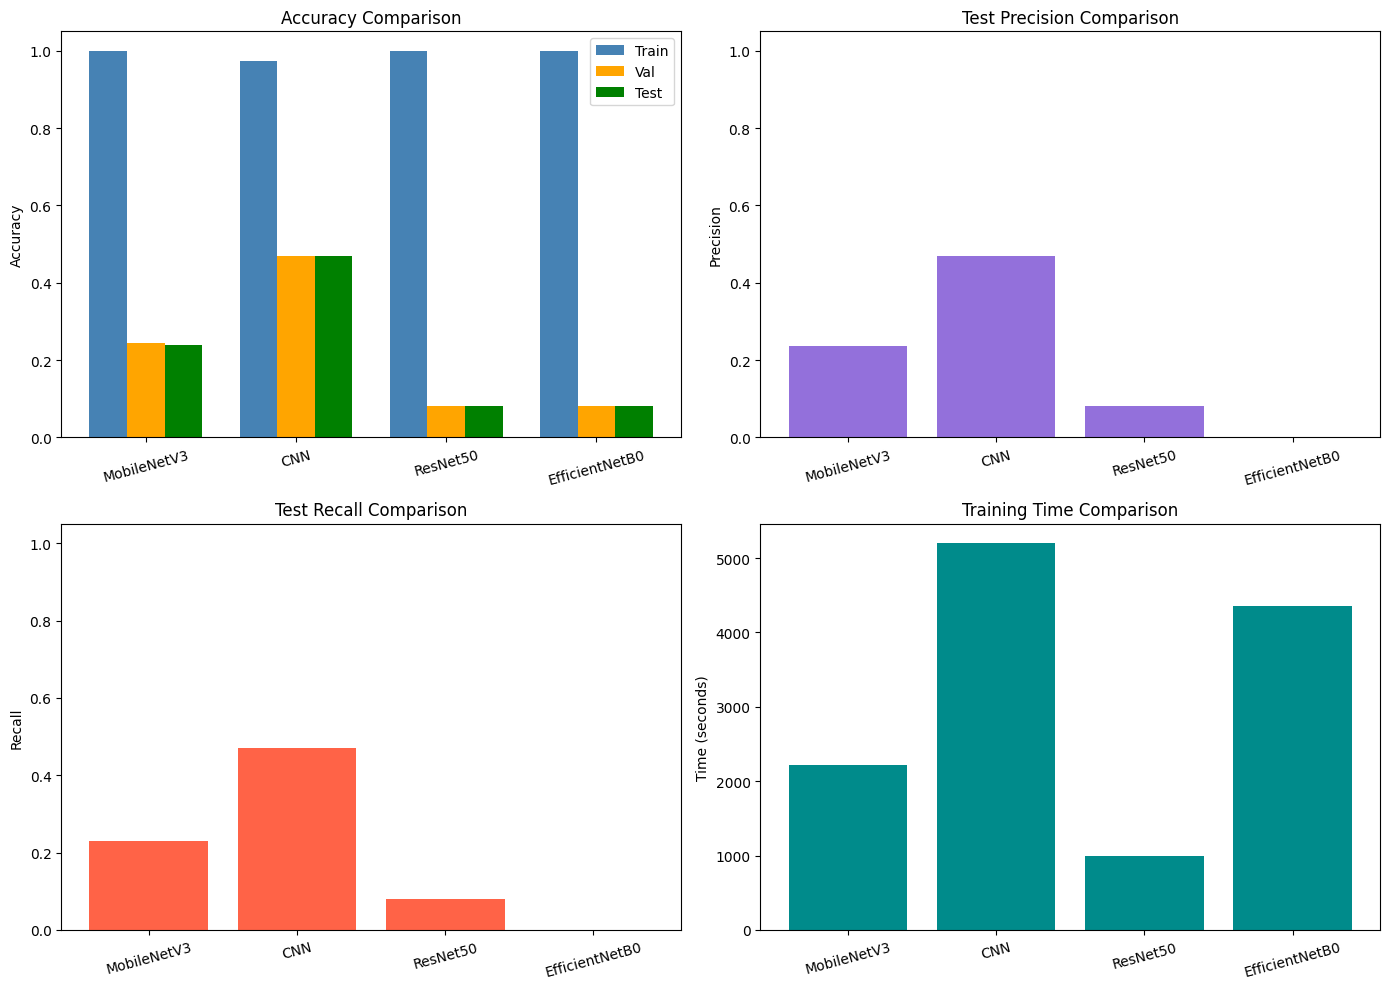

In [ ]:
model_names = ["MobileNetV3", "CNN", "ResNet50", "EfficientNetB0"]

train_accs  = [mob_train_acc,  cnn_train_acc,  rn_train_acc,  en_train_acc]
val_accs    = [mob_val_acc,    cnn_val_acc,    rn_val_acc,    en_val_acc]
test_accs   = [mob_test_acc,   cnn_test_acc,   rn_test_acc,   en_test_acc]
test_precs  = [mob_test_prec,  cnn_test_prec,  rn_test_prec,  en_test_prec]
test_recs   = [mob_test_rec,   cnn_test_rec,   rn_test_rec,   en_test_rec]
train_times = [mob_train_time, cnn_train_time, rn_train_time, en_train_time]

x = range(len(model_names))
width = 0.25

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
ax = axes[0, 0]
ax.bar([i - width for i in x], train_accs, width, label='Train', color='steelblue')
ax.bar([i          for i in x], val_accs,  width, label='Val',   color='orange')
ax.bar([i + width  for i in x], test_accs, width, label='Test',  color='green')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Comparison')
ax.legend()
ax.set_ylim(0, 1.05)

# Precision
ax = axes[0, 1]
ax.bar(model_names, test_precs, color='mediumpurple')
ax.set_ylabel('Precision')
ax.set_title('Test Precision Comparison')
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylim(0, 1.05)

# Recall
ax = axes[1, 0]
ax.bar(model_names, test_recs, color='tomato')
ax.set_ylabel('Recall')
ax.set_title('Test Recall Comparison')
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylim(0, 1.05)

# Training time
ax = axes[1, 1]
ax.bar(model_names, train_times, color='darkcyan')
ax.set_ylabel('Time (seconds)')
ax.set_title('Training Time Comparison')
ax.set_xticklabels(model_names, rotation=15)

plt.tight_layout()
plt.show()


### Training & Validation Loss — All Models

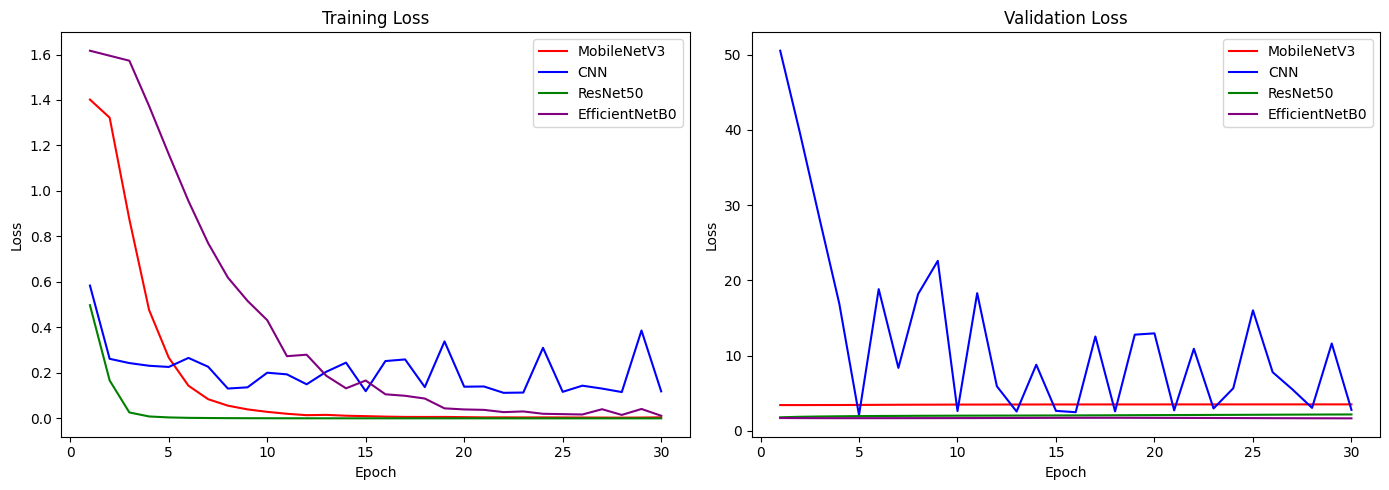

In [ ]:
all_histories = {
    "MobileNetV3":    mob_history.history,
    "CNN":            cnn_history.history,
    "ResNet50":       rn_history.history,
    "EfficientNetB0": en_history.history,
}

colors = ['red', 'blue', 'green', 'purple']
epochs = [i for i in range(1, 31)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, hist), color in zip(all_histories.items(), colors):
    axes[0].plot(epochs, hist['loss'],     color=color, label=name)
    axes[1].plot(epochs, hist['val_loss'], color=color, label=name)

axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


### Training & Validation Accuracy — All Models

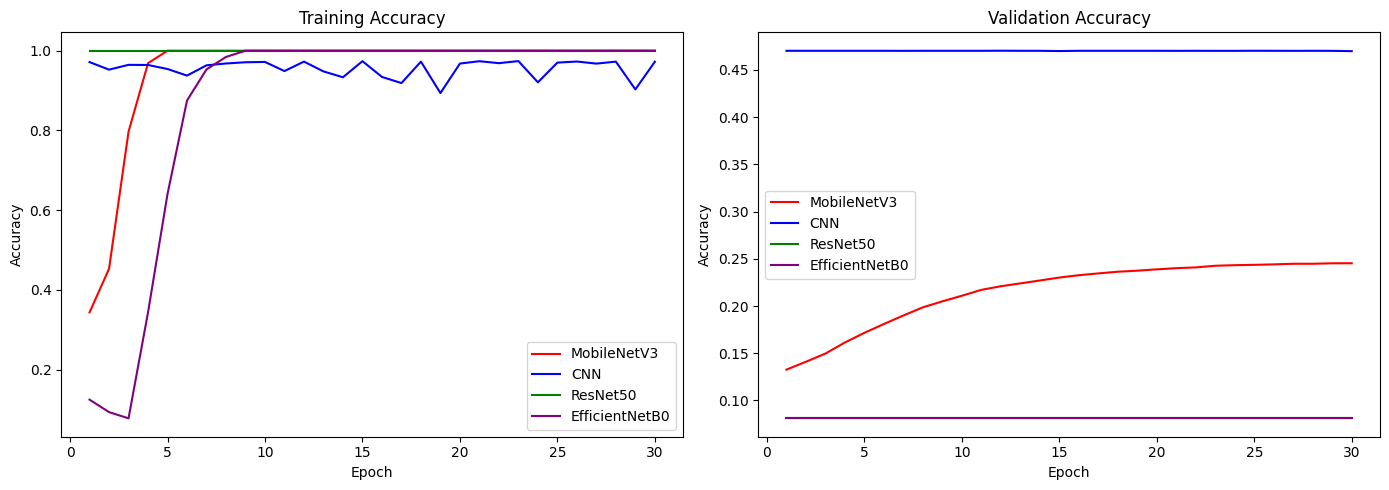

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, hist), color in zip(all_histories.items(), colors):
    axes[0].plot(epochs, hist['accuracy'],     color=color, label=name)
    axes[1].plot(epochs, hist['val_accuracy'], color=color, label=name)

axes[0].set_title('Training Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()
